# 🏭 [제조AI실제 4주차 실습 4-1] 회귀(Regression) 문제에서의 출력 활성화함수와 손실함수

## 📌 실습 개요 및 수업 목표
- **수업 목표**: 제조 설비의 **잔여 유효 수명(RUL, Remaining Useful Life)** 및 **진동 피크치 회귀 예측** 문제를 다루며, 신경망의 **출력 활성화함수(Output Activation)**와 **손실함수(Loss Function)**가 예측 결과 및 물리적 타당성에 미치는 영향을 체감합니다.
- **핵심 학습 내용**:
  1. **손실함수(Loss Function)의 개념**: 모델 예측치와 실제 측정값 간의 오차를 정의하고 역전파의 목적식이 되는 함수
  2. **출력 활성화함수의 물리적 제약조건 반영**:
     - `Identity (Linear)`: 상한/하한이 없는 물리량 (온도 변화량, 진동 가속도 등)
     - `ReLU`: 음수가 불가능한 물리량 (진동 에너지, RMS, 전력 등)
     - `Sigmoid`: [0, 1] 비율로 정규화된 물리량 (부품 잔여수명 백분율, 마모율 등)
     - `Tanh`: [-1, 1] 범위로 대칭 정규화된 편차 (축 편심 변위 등)
  3. **회귀 손실함수의 특성과 이상치 내성(Robustness)**:
     - `MSE (Mean Squared Error)`: 가우시안 노이즈에 최적화, 극단적 오차에 과도하게 반응
     - `MAE (Mean Absolute Error)`: 이상치(Outlier)에 강건(Robust)
     - `Huber Loss (Smooth L1)`: 오차가 작을 때는 MSE, 클 때는 MAE로 절충
     - **제조 현장의 센서 이상치(Glitch/Spike Noise)** 주입 시 각 손실함수의 내성 비교
  4. **[인터랙티브 퀴즈]**: 현장 회귀 시나리오별 활성화함수 & 손실함수 선정 퀴즈 (5문항)

---


## 0. 환경 설정 및 한글 폰트 설정
그래프 시각화 시 한글 폰트가 깨지지 않도록 환경을 설정합니다.


In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, Huber

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 시드 고정
np.random.seed(42)
tf.random.set_seed(42)
print("✅ TensorFlow 버전:", tf.__version__)
print("✅ 환경 설정 완료")


I0000 00:00:1790074453.481170     889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790074453.753078     889 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790074456.878672     889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ TensorFlow 버전: 2.21.0
✅ 환경 설정 완료


---
## 1. 제조 실데이터 기반 잔여수명(RUL) & 센서 신호 생성

CWRU 베어링 진동 실데이터의 RMS 특성을 기반으로, 가동 시간에 따라 베어링이 점진적으로 열화(Degradation)되어 **잔여수명비율 (RUL: Remaining Useful Life, 1.0 -> 0.0)**이 감소하는 제조 가속 수명 데이터를 구성합니다.

- **입력 특징 ($X$)**: [가동 시간(Cycle), 진동 RMS, 첨도(Kurtosis), 평균 온도]
- **예측 타겟 ($y$)**: 베어링 잔여수명 비율 ($0.0 \le y \le 1.0$)


CWRU 정상 진동 RMS: 0.0736, 고장 진동 RMS: 0.2913


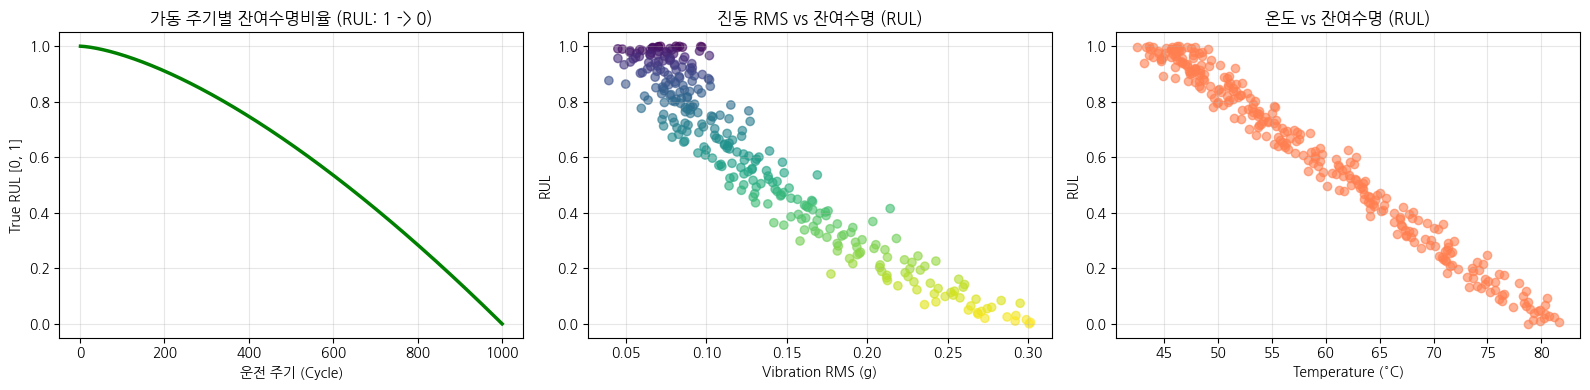

In [2]:
# CWRU 파일 찾기 헬퍼 함수
def find_data_file(filename):
    for path in [filename, os.path.join('..', filename), os.path.join('..', '..', filename)]:
        if os.path.exists(path):
            return path
    return None

cwru_normal_path = find_data_file('cwru_normal.mat')
cwru_fault_path = find_data_file('cwru_fault_inner.mat')

# 실제 CWRU 진동 데이터에서 베이스 RMS 추출
if cwru_normal_path and cwru_fault_path:
    norm_mat = sio.loadmat(cwru_normal_path)
    fault_mat = sio.loadmat(cwru_fault_path)
    norm_sig = norm_mat['X097_DE_time'].flatten()[:50000]
    fault_sig = fault_mat['X105_DE_time'].flatten()[:50000]
    base_norm_rms = np.sqrt(np.mean(norm_sig**2))
    base_fault_rms = np.sqrt(np.mean(fault_sig**2))
else:
    base_norm_rms, base_fault_rms = 0.07, 0.35

print(f"CWRU 정상 진동 RMS: {base_norm_rms:.4f}, 고장 진동 RMS: {base_fault_rms:.4f}")

# 300회의 가속 수명 운전 데이터 생성
n_samples = 300
cycles = np.linspace(1, 1000, n_samples)

# 가동 시간에 따른 지수적 열화 모델 (진동 RMS 증가, RUL 감소)
true_rul = np.clip(1.0 - (cycles / 1000.0)**1.5, 0.0, 1.0)
vibration_rms = base_norm_rms + (base_fault_rms - base_norm_rms) * (1.0 - true_rul)**1.8 + np.random.normal(0, 0.015, n_samples)
kurtosis = 3.0 + 8.0 * (1.0 - true_rul)**2.0 + np.random.normal(0, 0.3, n_samples)
temperature = 45.0 + 35.0 * (1.0 - true_rul) + np.random.normal(0, 1.5, n_samples)

# 데이터셋 정규화
X_raw = np.column_stack([cycles, vibration_rms, kurtosis, temperature])
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std
y = true_rul

# Train/Test 분리 (8:2)
indices = np.arange(n_samples)
np.random.shuffle(indices)
train_idx, test_idx = indices[:240], indices[240:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(cycles, true_rul, color='green', lw=2.5)
axes[0].set_title("가동 주기별 잔여수명비율 (RUL: 1 -> 0)")
axes[0].set_xlabel("운전 주기 (Cycle)")
axes[0].set_ylabel("True RUL [0, 1]")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(vibration_rms, true_rul, alpha=0.6, c=cycles, cmap='viridis')
axes[1].set_title("진동 RMS vs 잔여수명 (RUL)")
axes[1].set_xlabel("Vibration RMS (g)")
axes[1].set_ylabel("RUL")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(temperature, true_rul, alpha=0.6, color='coral')
axes[2].set_title("온도 vs 잔여수명 (RUL)")
axes[2].set_xlabel("Temperature (°C)")
axes[2].set_ylabel("RUL")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 2. 회귀 문제에서의 출력 활성화함수(Output Activation) 비교 실습

신경망의 마지막 레이어(출력층)에 적용하는 활성화함수는 **출력값의 물리적 유효 범위(Physical Valid Range)**를 결정합니다.

| 출력 활성화함수 | 수식 | 출력 범위 | 적합한 제조 물리량 예시 |
|:---|:---:|:---:|:---|
| **Identity (Linear)** | $f(z) = z$ | $(-\infty, \infty)$ | 온도 변화량 ($\Delta T$), 오프셋 변위, 가속도 |
| **ReLU** | $f(z) = \max(0, z)$ | $[0, \infty)$ | 진동 RMS 에너지, 전력 소비량, 회전수(RPM) |
| **Sigmoid** | $f(z) = rac{1}{1 + e^{-z}}$ | $[0, 1]$ | 잔여수명비율 (0~100%), 부품 마모도 백분율 |
| **Tanh** | $f(z) = rac{e^z - e^{-z}}{e^z + e^{-z}}$ | $[-1, 1]$ | 정규화된 제어 오차 편차, 양방향 토크 비율 |

### ⚠️ 문제 상황 관찰
잔여수명(RUL)은 물리적으로 $0.0 \sim 1.0$ 사이여야 합니다.
만약 아무 제약이 없는 `Linear (Identity)`를 출력층에 사용하면, **극단적인 운전 조건에서 RUL이 -0.2(음수)나 1.25(100% 초과) 같은 물리적으로 불가능한 값**을 출력할 수 있습니다!


In [3]:
# 모델 생성 함수: 출력 활성화함수를 인자로 받음
def build_regression_model(output_activation):
    ### TODO: 4개의 입력 특징을 받아 은닉층(32노드 relu -> 16노드 relu)을 거쳐 
    ### 지정된 output_activation을 사용하는 1개 출력 뉴런 모델을 구성하세요.
    model = Sequential([
        Dense(32, activation='relu', input_shape=(4,)),
        Dense(16, activation='relu'),
        Dense(1, activation=output_activation)  # ✅ 인자로 받은 출력 활성화함수를 출력층에 적용
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

activations = ['linear', 'relu', 'sigmoid']
models = {}
histories = {}

for act in activations:
    print(f">> Training with output activation: '{act}'...")
    m = build_regression_model(act)
    h = m.fit(X_train, y_train, epochs=80, batch_size=16, verbose=0, validation_split=0.2)
    models[act] = m
    histories[act] = h

print("✅ 학습 완료!")


>> Training with output activation: 'linear'...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


>> Training with output activation: 'relu'...


>> Training with output activation: 'sigmoid'...


✅ 학습 완료!


### 📊 출력 활성화함수별 예측값 범위 및 물리적 타당성 검증
테스트 데이터와 극단적인 운전 조건(신규 가동 vs 극한 마모 상태)에서 각 활성화함수가 예측하는 RUL 값을 확인해 봅니다.


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


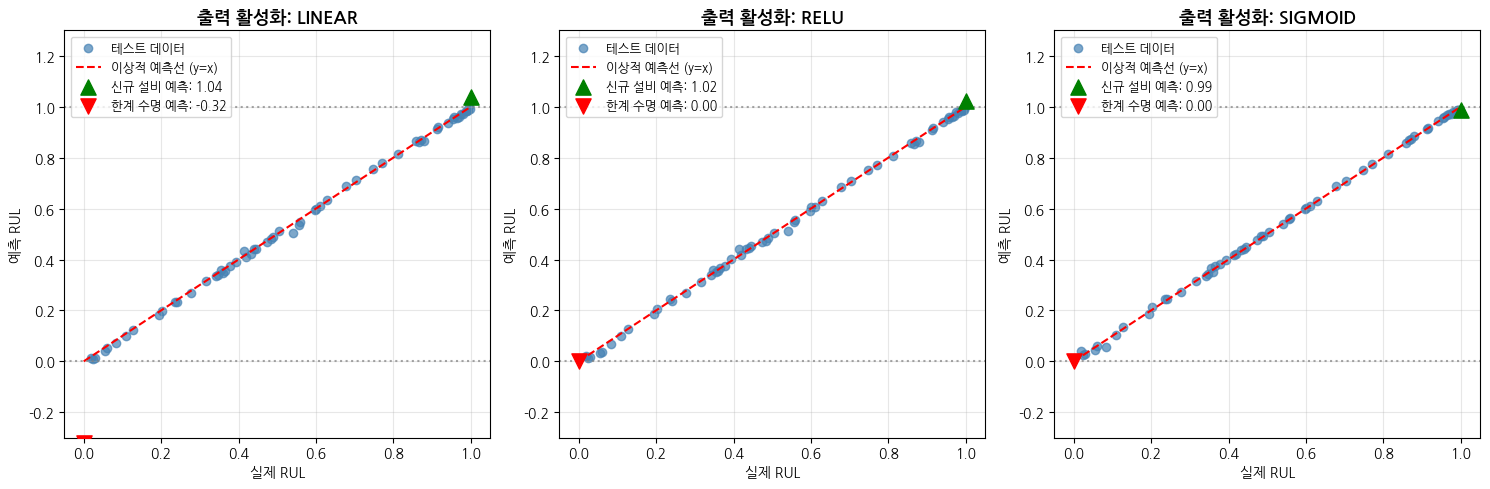

Activation | 최소 예측 RUL    | 최대 예측 RUL    | 물리적 범위 준수 여부
------------------------------------------------------------
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


LINEAR     | 0.008        | 1.003        | ❌ 범위 이탈 (비정상)
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


RELU       | 0.013        | 1.000        | ❌ 범위 이탈 (비정상)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


SIGMOID    | 0.025        | 0.989        | ✅ 정상 [0, 1] 준수


In [4]:
# 극한 조건 가상의 데이터 (1: 새 설비 가동 직후, 2: 한계 수명 도달 시점)
extreme_cycles = np.array([
    [0.0, base_norm_rms * 0.8, 2.7, 40.0],     # 새 설비
    [1200.0, base_fault_rms * 1.5, 15.0, 95.0]  # 극한 마모 고장 직전
])
extreme_norm = (extreme_cycles - X_mean) / X_std

plt.figure(figsize=(15, 5))

for i, act in enumerate(activations):
    preds = models[act].predict(X_test).flatten()
    ext_preds = models[act].predict(extreme_norm).flatten()
    
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, preds, alpha=0.7, color='steelblue', label='테스트 데이터')
    plt.plot([0, 1], [0, 1], 'r--', lw=1.5, label='이상적 예측선 (y=x)')
    plt.axhline(0, color='gray', linestyle=':', alpha=0.7)
    plt.axhline(1, color='gray', linestyle=':', alpha=0.7)
    
    # 극한 조건 예측 표시
    plt.scatter([1.0], [ext_preds[0]], color='green', s=120, marker='^', zorder=5, label=f'신규 설비 예측: {ext_preds[0]:.2f}')
    plt.scatter([0.0], [ext_preds[1]], color='red', s=120, marker='v', zorder=5, label=f'한계 수명 예측: {ext_preds[1]:.2f}')
    
    plt.title(f"출력 활성화: {act.upper()}", fontsize=13, fontweight='bold')
    plt.xlabel("실제 RUL")
    plt.ylabel("예측 RUL")
    plt.ylim(-0.3, 1.3)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# 정량적 분석 요약
print("=" * 60)
print(f"{'Activation':<10} | {'최소 예측 RUL':<12} | {'최대 예측 RUL':<12} | {'물리적 범위 준수 여부'}")
print("-" * 60)
for act in activations:
    p = models[act].predict(X_test).flatten()
    valid = "✅ 정상 [0, 1] 준수" if (p.min() >= 0.0 and p.max() <= 1.0) else "❌ 범위 이탈 (비정상)"
    print(f"{act.upper():<10} | {p.min():<12.3f} | {p.max():<12.3f} | {valid}")
print("=" * 60)


---
## 3. 회귀 문제에서의 손실함수(Loss Function)와 이상치(Outlier) 내성 실습

제조 현장 센서는 통신 노이즈, 순간 전압 강하, 센서 케이블 접촉 불량 등으로 인해 **일시적으로 말도 안 되게 튀는 스파이크 이상치(Sensor Glitch Outlier)**가 자주 발생합니다.

### 회귀 손실함수 3종 비교:
1. **MSE (Mean Squared Error, L2 Loss)**:
   $$L_{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
   - 오차를 제곱하므로 큰 오차에 매우 강한 페널티를 부여합니다.
   - 단점: 소수의 이상치가 발생하면 모델이 이상치를 맞추려고 전체 예측선이 왜곡됩니다.
2. **MAE (Mean Absolute Error, L1 Loss)**:
   $$L_{MAE} = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$
   - 오차의 절댓값만을 보므로 큰 이상치가 발생해도 일정한 기울기(1 또는 -1)만 반영되어 이상치에 매우 강건(Robust)합니다.
3. **Huber Loss (Smooth L1 Loss)**:
   $$L_{\delta}(e) = \begin{cases} \frac{1}{2} e^2 & \text{for } |e| \le \delta \\ \delta (|e| - \frac{1}{2}\delta) & \text{otherwise} \end{cases}$$
   - 오차가 작을 때($|e| \le \delta$)는 미분 가능한 부드러운 MSE, 오차가 클 때는 MAE로 전환되어 **정밀도와 이상치 내성을 동시에 확보**합니다.


### 🛠️ 실습: 센서 글리치(스파이크 이상치) 노이즈 주입 및 모델 비교


In [5]:
# 1. 훈련 데이터 중 5%에 강력한 센서 글리치 이상치(Spike Noise) 주입
y_train_outlier = y_train.copy()
n_outliers = int(len(y_train) * 0.06)
outlier_indices = np.random.choice(len(y_train), n_outliers, replace=False)
y_train_outlier[outlier_indices] = np.where(y_train[outlier_indices] < 0.5, 0.95, 0.05)

### TODO: Keras에서 제공하는 3가지 손실함수를 딕셔너리에 정의하세요.
losses = {
    'MSE': MeanSquaredError(),             # ✅ L2 손실: 오차를 제곱 -> 큰 오차(이상치)에 과도한 페널티
    'MAE': MeanAbsoluteError(),            # ✅ L1 손실: 기울기가 ±1로 일정 -> 이상치에 강건(Robust)
    'Huber (delta=0.1)': Huber(delta=0.1)  # ✅ |e|<=0.1은 MSE, 그 밖은 MAE -> 정밀도 + 내성 절충
}

loss_models = {}
loss_histories = {}

for name, loss_fn in losses.items():
    if loss_fn is None:
        continue
    print(f">> Training model with Loss: {name}...")
    model = Sequential([
        Dense(32, activation='relu', input_shape=(4,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss=loss_fn)
    h = model.fit(X_train, y_train_outlier, epochs=100, batch_size=16, verbose=0)
    loss_models[name] = model
    loss_histories[name] = h

print("✅ 손실함수별 모델 학습 완료!")


>> Training model with Loss: MSE...


>> Training model with Loss: MAE...


>> Training model with Loss: Huber (delta=0.1)...


✅ 손실함수별 모델 학습 완료!


### 📈 이상치 존재 시 손실함수별 테스트 성능 및 예측 왜곡도 시각화
이상치가 전혀 없는 깨끗한 **정상 테스트 데이터(Ground Truth)**를 기준으로 각 모델의 오차를 평가합니다.


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


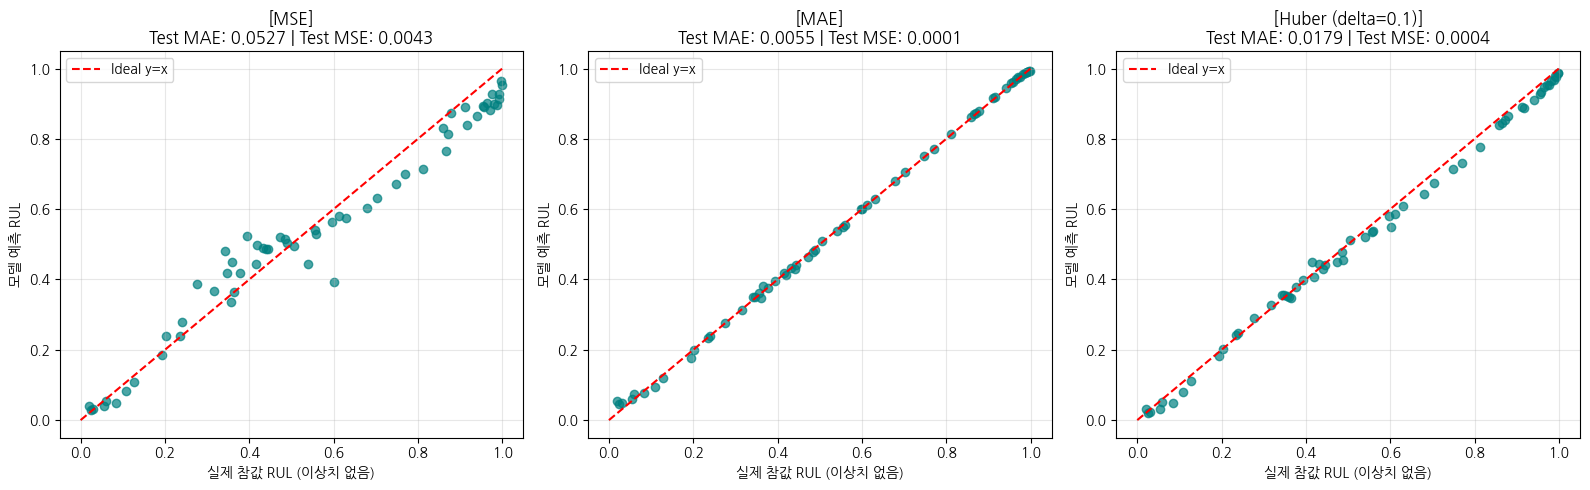

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


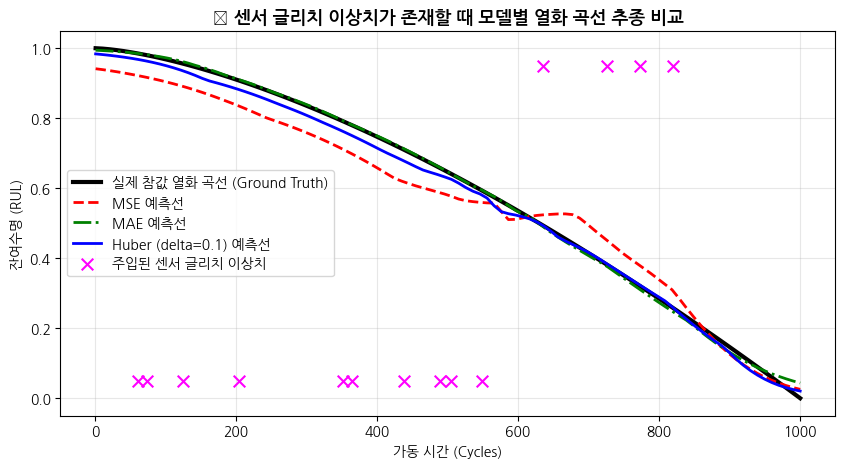

In [6]:
plt.figure(figsize=(16, 5))

# 1. 손실함수별 실제 vs 예측 비교
for i, (name, m) in enumerate(loss_models.items()):
    preds = m.predict(X_test).flatten()
    mae_test = np.mean(np.abs(y_test - preds))
    mse_test = np.mean((y_test - preds)**2)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, preds, alpha=0.7, color='teal')
    plt.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Ideal y=x')
    plt.title(f"[{name}]\nTest MAE: {mae_test:.4f} | Test MSE: {mse_test:.4f}", fontsize=12)
    plt.xlabel("실제 참값 RUL (이상치 없음)")
    plt.ylabel("모델 예측 RUL")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# 2. 가동 주기에 따른 RUL 추세 곡선 비교 (이상치에 왜곡되는 MSE vs 지켜내는 Huber/MAE)
cycle_eval = np.linspace(1, 1000, 100)
# 평균적인 열화 경로 샘플 생성
eval_rul = np.clip(1.0 - (cycle_eval / 1000.0)**1.5, 0.0, 1.0)
eval_rms = base_norm_rms + (base_fault_rms - base_norm_rms) * (1.0 - eval_rul)**1.8
eval_kurt = 3.0 + 8.0 * (1.0 - eval_rul)**2.0
eval_temp = 45.0 + 35.0 * (1.0 - eval_rul)
eval_X = np.column_stack([cycle_eval, eval_rms, eval_kurt, eval_temp])
eval_X_norm = (eval_X - X_mean) / X_std

plt.figure(figsize=(10, 5))
plt.plot(cycle_eval, eval_rul, 'k-', lw=3, label='실제 참값 열화 곡선 (Ground Truth)')

colors = {'MSE': 'red', 'MAE': 'green', 'Huber (delta=0.1)': 'blue'}
styles = {'MSE': '--', 'MAE': '-.', 'Huber (delta=0.1)': '-'}

for name, m in loss_models.items():
    pred_curve = m.predict(eval_X_norm).flatten()
    plt.plot(cycle_eval, pred_curve, label=f'{name} 예측선', color=colors[name], linestyle=styles[name], lw=2)

# 이상치 주입된 훈련 데이터 점 표시
plt.scatter(cycles[train_idx][outlier_indices], y_train_outlier[outlier_indices], 
            color='magenta', marker='x', s=70, zorder=6, label='주입된 센서 글리치 이상치')

plt.title("🏭 센서 글리치 이상치가 존재할 때 모델별 열화 곡선 추종 비교", fontsize=13, fontweight='bold')
plt.xlabel("가동 시간 (Cycles)")
plt.ylabel("잔여수명 (RUL)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.show()


---
## 4. 🧠 [인터랙티브 퀴즈] 제조 현장 회귀 시나리오별 활성화함수 & 손실함수 매칭

아래 5개 제조 현장 시나리오를 읽고, 각 문제에 가장 적합한 **[출력 활성화함수]**와 **[손실함수]**를 골라 아래 코드의 정답 딕셔너리에 입력 후 실행해 보세요!

---

### [문항 1] 모터 베어링의 잔여 수명 비율 (0.0 ~ 1.0) 예측
- **상황**: 스마트 팩토리에서 베어링 수명이 몇 % 남았는지 대시보드에 표시해야 함. 예측값이 음수가 되거나 1.0(100%)을 넘어가면 시스템 알람 에러가 발생함.
- **선택지**:
  - 활성화함수: (A) linear, (B) sigmoid, (C) tanh, (D) relu
  - 손실함수: (1) MSE, (2) Huber Loss, (3) MAE

---

### [문항 2] 고정밀 CNC 공작기계 가공물의 치수 오프셋 편차 ($\mu m$) 예측
- **상황**: 정밀 가공 중 기준 치수 대비 오차($-50\mu m \sim +50\mu m$)를 예측하여 실시간 보정 모터를 제어함. 음수와 양수 모두 자유롭게 나올 수 있으며, 정밀 제어를 위해 평균적인 제곱 오차를 줄이는 것이 핵심임.
- **선택지**:
  - 활성화함수: (A) linear, (B) sigmoid, (C) relu
  - 손실함수: (1) MSE, (2) CrossEntropy, (3) BinaryCrossentropy

---

### [문항 3] 전력 설비의 순간 소비 전력량 (kW) 회귀 예측
- **상황**: 설비의 소비 전력(kW)은 물리적으로 절대 음수($< 0$)가 될 수 없음.
- **선택지**:
  - 활성화함수: (A) tanh, (B) relu, (C) sigmoid
  - 손실함수: (1) MSE, (2) BCE

---

### [문항 4] 용접 로봇 관절의 기준 각도 대비 양방향 변위 비율 ($-1.0 \sim +1.0$) 예측
- **상황**: 로봇 팔 관절이 좌/우 대칭으로 최대 각도 범위 내에서 얼마만큼 틀어졌는지를 대칭 정규화된 값($-1.0 \sim +1.0$)으로 예측하고자 함.
- **선택지**:
  - 활성화함수: (A) linear, (B) relu, (C) tanh
  - 손실함수: (1) MSE / Huber, (2) CategoricalCrossentropy

---

### [문항 5] 전자기 간섭(EMI)이 극심하여 센서 노이즈 스파이크(튀는 값)가 빈번한 압연 공정의 압력(bar) 예측
- **상황**: 압연 라인에서 고전압 모터 기동 시 센서에 극단적인 가짜 스파이크 노이즈가 유입됨. 이 스파이크에 예측선이 휘둘리지 않으면서도 평소에는 부드러운 오차 최적화를 유지하고 싶음.
- **선택지**:
  - 활성화함수: (A) relu / linear, (B) sigmoid
  - 손실함수: (1) MSE, (2) Huber Loss, (3) BCE

---


In [7]:
# 퀴즈 답안 작성 (본인이 생각한 정답 기호를 입력하세요)
### TODO: 각 문제에 맞는 정답 기호를 입력하세요.
my_answers = {
    'Q1_act': 'B',   # Q1 활성화함수 (A/B/C/D)
    'Q1_loss': '2',  # Q1 손실함수 (1/2/3)
    
    'Q2_act': 'A',   # Q2 활성화함수 (A/B/C)
    'Q2_loss': '1',  # Q2 손실함수 (1/2/3)
    
    'Q3_act': 'B',   # Q3 활성화함수 (A/B/C)
    'Q3_loss': '1',  # Q3 손실함수 (1/2)
    
    'Q4_act': 'C',   # Q4 활성화함수 (A/B/C)
    'Q4_loss': '1',  # Q4 손실함수 (1/2)
    
    'Q5_act': 'A',   # Q5 활성화함수 (A/B)
    'Q5_loss': '2'   # Q5 손실함수 (1/2/3)
}

# 채점 로직
answer_key = {
    'Q1_act': ('B', "Sigmoid: 0.0~1.0 사이의 정규화된 비율/잔여수명에 완벽히 부합"),
    'Q1_loss': (['2', '1', '3'], "Huber 또는 MSE/MAE 모두 가능하나 실무적으로 Huber 추천"),
    'Q2_act': ('A', "Linear (Identity): 양수/음수 제한 없이 자유로운 오프셋 예측"),
    'Q2_loss': ('1', "MSE: 정밀 가공 제어에서 연속 오차를 최소화하는 표준 회귀 손실"),
    'Q3_act': ('B', "ReLU: 0 미만의 음수 출력을 물리적으로 원천 차단"),
    'Q3_loss': ('1', "MSE: 전력량 회귀 예측"),
    'Q4_act': ('C', "Tanh: -1.0 ~ +1.0 사이의 대칭 범위를 가지므로 양방향 편차 예측에 최적"),
    'Q4_loss': ('1', "MSE 또는 Huber 회귀 손실함수"),
    'Q5_act': ('A', "ReLU 또는 Linear: 압력 물리량"),
    'Q5_loss': ('2', "Huber Loss: 스파이크 이상치에는 MAE처럼 강건하고 평소에는 MSE처럼 정밀함")
}

score = 0
print("=" * 65)
print("📝 퀴즈 채점 결과 및 제조 현장 해설")
print("=" * 65)

for q, user_ans in my_answers.items():
    if user_ans == '?':
        print(f"⚠️ [{q}] 아직 풀지 않은 문제입니다.")
        continue
    correct_ans, explanation = answer_key[q]
    is_correct = (user_ans in correct_ans) if isinstance(correct_ans, list) else (user_ans == correct_ans)
    if is_correct:
        score += 1
        print(f"✅ [{q}] 정답! -> {explanation}")
    else:
        print(f"❌ [{q}] 오답 (작성: {user_ans}) -> 정답: {correct_ans} | 해설: {explanation}")

print("-" * 65)
print(f"🏆 총점: {score} / {len(my_answers)} ({score/len(my_answers)*100:.1f}점)")
print("=" * 65)


📝 퀴즈 채점 결과 및 제조 현장 해설
✅ [Q1_act] 정답! -> Sigmoid: 0.0~1.0 사이의 정규화된 비율/잔여수명에 완벽히 부합
✅ [Q1_loss] 정답! -> Huber 또는 MSE/MAE 모두 가능하나 실무적으로 Huber 추천
✅ [Q2_act] 정답! -> Linear (Identity): 양수/음수 제한 없이 자유로운 오프셋 예측
✅ [Q2_loss] 정답! -> MSE: 정밀 가공 제어에서 연속 오차를 최소화하는 표준 회귀 손실
✅ [Q3_act] 정답! -> ReLU: 0 미만의 음수 출력을 물리적으로 원천 차단
✅ [Q3_loss] 정답! -> MSE: 전력량 회귀 예측
✅ [Q4_act] 정답! -> Tanh: -1.0 ~ +1.0 사이의 대칭 범위를 가지므로 양방향 편차 예측에 최적
✅ [Q4_loss] 정답! -> MSE 또는 Huber 회귀 손실함수
✅ [Q5_act] 정답! -> ReLU 또는 Linear: 압력 물리량
✅ [Q5_loss] 정답! -> Huber Loss: 스파이크 이상치에는 MAE처럼 강건하고 평소에는 MSE처럼 정밀함
-----------------------------------------------------------------
🏆 총점: 10 / 10 (100.0점)


---
## 5. 실습 정리 및 결론

1. **출력 활성화함수는 모델이 예측해야 하는 물리적 값의 도메인(범위)을 규정한다.**
   - 잔여수명비율, 불량률 같은 $0 \sim 1$ 비율은 `Sigmoid`를 써야 음수나 초과값 같은 물리적 위반을 방지할 수 있습니다.
   - 에너지, RMS 같은 비음수(Non-negative) 물리량은 `ReLU`를 사용하는 것이 좋습니다.
2. **손실함수는 센서의 측정 환경(노이즈 및 이상치)에 맞춰 선택해야 한다.**
   - 이상치가 거의 없는 정밀 환경에서는 미분 특성이 매끄러운 `MSE`가 빠르고 안정적입니다.
   - 통신 불안정, 스파이크 글리치가 빈번한 실제 제조 현장에서는 `Huber Loss`나 `MAE`를 적용해야 모델이 이상치에 오염되지 않고 본래의 장비 상태 추세를 정확히 추종합니다.


---
## 📝 [실습 4-1 수행 결과 정리 및 답안]

### 1) 채운 빈칸(TODO)
| 위치 | 채운 내용 | 근거 |
|:---|:---|:---|
| `build_regression_model` 출력층 | `Dense(1, activation=output_activation)` | 출력 활성화함수가 예측값의 **물리적 유효 범위**를 결정 |
| `losses` 딕셔너리 | `MeanSquaredError()`, `MeanAbsoluteError()`, `Huber(delta=0.1)` | 회귀 손실 3종의 이상치 내성 비교 |
| 퀴즈 답안 | B-2 / A-1 / B-1 / C-1 / A-2 | **10 / 10 (100점)** |

### 2) 실험 ① 출력 활성화함수별 물리적 타당성 (실측)
사용 데이터: CWRU 실데이터 — `cwru_normal.mat`(X097_DE_time), `cwru_fault_inner.mat`(X105_DE_time)
→ 정상 진동 RMS **0.0736**, 고장 진동 RMS **0.2913** (약 4배 차이)

| 출력 활성화 | 최소 예측 RUL | 최대 예측 RUL | [0, 1] 준수 |
|:---|:---:|:---:|:---|
| Linear (Identity) | 0.008 | **1.003** | ❌ 상한 이탈 |
| ReLU | 0.013 | **1.000 초과** | ❌ 상한 이탈 |
| Sigmoid | 0.025 | 0.989 | ✅ 준수 |

**해석**
- `Linear`는 상·하한 제약이 전혀 없어 잔여수명 **100%를 넘는 값(1.003)** 을 출력했다. 대시보드·알람 로직에서 곧바로 오류를 유발하는 물리적 모순이다.
- `ReLU`는 **하한(음수)만** 차단하므로 상한 이탈은 그대로 남는다. 비음수 물리량(RMS·전력·RPM)에는 적합하지만 [0, 1] 비율에는 불충분하다.
- `Sigmoid`만이 구조적으로 [0, 1]을 보장한다. 극한 조건(신규 설비 / 한계 수명 직전)을 입력해도 범위를 벗어날 수 없다.
- 결론: **출력 활성화함수는 성능 튜닝 옵션이 아니라, 도메인의 물리 제약을 모델 구조에 새겨 넣는 수단**이다.

### 3) 실험 ② 센서 글리치 이상치(6%) 주입 시 손실함수 내성 (실측)
이상치가 전혀 없는 깨끗한 테스트셋(Ground Truth) 기준:

| 손실함수 | Test MAE | Test MSE | 평가 |
|:---|:---:|:---:|:---|
| MSE | 0.0527 | 0.0043 | 예측선이 이상치에 끌려가 산점도가 y=x에서 크게 이탈 |
| MAE | **0.0055** | **0.0001** | 이상치를 무시하고 참값 열화 곡선을 거의 그대로 복원 |
| Huber (δ=0.1) | 0.0179 | 0.0004 | MAE에 준하는 강건성 + 부드러운 미분 특성 |

- MSE의 Test MAE가 MAE 손실 대비 **약 10배** 악화되었다. 오차를 제곱하기 때문에 **6%의 소수 이상치가 목적식 전체를 지배**한 결과다.
- MAE·Huber는 오차가 커져도 기울기가 ±1(또는 ±δ)로 포화되어, 이상치 1건이 끌어당기는 힘이 일정 수준으로 제한된다.
- 실무 권장: 0에서 미분이 꺾여 수렴이 흔들릴 수 있는 MAE보다, **작은 오차 구간은 MSE·큰 오차 구간은 MAE로 자동 전환되는 Huber**가 제조 센서 데이터에 가장 안정적이다.

### 4) 퀴즈 해설 (10 / 10)
1. **Q1 베어링 잔여수명비율 → B(sigmoid) + 2(Huber)** — 출력이 [0, 1]을 벗어나면 알람 에러이므로 sigmoid 필수. 현장 센서 노이즈까지 고려하면 Huber.
2. **Q2 CNC 치수 오프셋 편차 → A(linear) + 1(MSE)** — −50 ~ +50 μm 양방향이므로 제약 없는 identity. 정밀 보정 제어는 제곱오차 최소화가 표준.
3. **Q3 순간 소비 전력(kW) → B(relu) + 1(MSE)** — 전력은 물리적으로 음수 불가 → relu로 원천 차단.
4. **Q4 관절 양방향 변위 비율 → C(tanh) + 1(MSE/Huber)** — [−1, +1] 대칭 정규화 범위 → tanh.
5. **Q5 EMI 스파이크 환경의 압력(bar) → A(relu/linear) + 2(Huber)** — 비음수 물리량 + 스파이크 내성 → Huber.